<a href="https://colab.research.google.com/github/sheliabond/Prescriptive-Analytics---Spring-2026-Public-/blob/main/Assignments/02ResourceAllocationSensitivity/assignment_template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Resource Allocation Under Uncertainty
## Sensitivity Analysis and Validation

**Student Name:** [Your Name]  
**Date:** [Date]  
**Chosen context:** [e.g. Marketing – ad spend across channels]

## Assignment Overview

You will choose a resource allocation problem in your field, create a small synthetic dataset (CSV), build an optimization model, run sensitivity analysis and validation, then respond to a **stakeholder change of mind** with an updated model and comparison. The deliverable is one notebook with clear documentation and an executive summary suitable to hand off to a manager.

**Learning Objectives:**
- Identify a resource allocation decision in your field
- Distinguish decision variables vs inputs; list 3 key parameters with uncertainty
- Perform sensitivity analysis (vary 3 parameters ±20%); identify most critical parameter
- Run one what-if scenario and compare to base
- Apply validation (sanity checks, robust vs fragile)
- Part 2: Respond to stakeholder change of mind; update model; comparison visualization; impact analysis
- Communicate results in an elegant final write-up


In [4]:
# Install required packages (if needed in Colab)
# Skip if running locally and packages are already installed
%pip install pulp pandas matplotlib -q


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pulp import LpMaximize, LpMinimize, LpProblem, LpVariable, lpSum, value, LpStatus
import io

print("Libraries imported successfully!")


Libraries imported successfully!


## Creating Your Synthetic Dataset

Because each student uses a different field, there is no single provided dataset. You will **create a synthetic (made-up) dataset** as **CSV** that fits your chosen context.

**Required size:** Exactly **5 records** (5 rows). Each record = one option to allocate to (e.g. one channel, one segment, one shift type, one player, one project).

**What your dataset must include:**
1. **Exactly 5 options** (5 rows) with one row per option.
2. **At least two numeric columns per option** (e.g. cost per unit, conversion rate, default rate). You need at least two so that you have two parameters to vary in sensitivity analysis (see Section 1.4 below).
3. **One overall constraint value** (e.g. total budget, total hours). This is the "limited resource" cap for the **whole scenario**—one number, not per row. You do **not** put it in the CSV. You get it from the language model (e.g. "budget = 10000") and set it in your notebook code (e.g. `budget_total = 10000`). This single number is your **third parameter** for sensitivity.

**Where do the "three parameters" come from?** Later in the assignment (Section 1.4 and Part 2 sensitivity) you will list **3 key parameters** and vary each by ±20%. Those three are: **(1)** and **(2)** two numeric inputs from your options table (e.g. cost per unit and conversion rate), and **(3)** the overall constraint (e.g. budget total). The CSV has only the two numeric columns; the constraint is **one number you set in code** (e.g. `budget_total = 10000`), not a column in the CSV.

**Steps (use a language model such as ChatGPT, Claude, or Copilot):**
1. Open a **new** conversation.
2. Say what decision you are modeling and your context (marketing, credit risk, staff, baseball, or generic). State: "I need a synthetic dataset with **exactly 5 records** (5 options) for a resource allocation optimization. I will use it in Python with pandas and PuLP. I need the data as **CSV only**."
3. Ask: "Please give me the data as a **CSV**. First row = column headers. Include **exactly 5 rows** (one per option). Include columns for: [list columns for your context, e.g. option name, cost per unit, conversion rate]. Also give me the single constraint value (e.g. total budget). Output only the CSV and the constraint value; no extra text."
4. Say: "Use realistic but simple numbers. The table must have **exactly 5 rows**—no more, no fewer."
5. Copy the CSV from the reply and paste it into the next code cell (as a string or by saving to `options_data.csv`). Load it with `pd.read_csv()` and set your constraint variable (e.g. `budget_total`).

See the **README** for example prompts by context (marketing, credit risk, staff, baseball, generic).


In [40]:
csv_string = """
credit_tier,loss_rate,yield
A++,0.03,0.15
A+,0.05,0.12
A,0.01,0.08
B,0.04,0.13
C,0.07,0.18
"""
options_df = pd.read_csv(io.StringIO(csv_string.strip()))
total_loan_capital = 10000000  # Constraint value for total loan capital

print(options_df)
print(f"\nConstraint (e.g. total_loan_capital): {total_loan_capital}")
print(f"Number of options (rows): {len(options_df)}")

print("Options DataFrame with loss_rate and yield displayed as percentages:")
# Create a copy to avoid modifying the original DataFrame for display purposes
formatted_options_df = options_df.copy()
formatted_options_df['loss_rate'] = formatted_options_df['loss_rate'].apply(lambda x: f"{x:.2%}")
formatted_options_df['yield'] = formatted_options_df['yield'].apply(lambda x: f"{x:.2%}")
display(formatted_options_df)

  credit_tier  loss_rate  yield
0         A++       0.03   0.15
1          A+       0.05   0.12
2           A       0.01   0.08
3           B       0.04   0.13
4           C       0.07   0.18

Constraint (e.g. total_loan_capital): 10000000
Number of options (rows): 5
Options DataFrame with loss_rate and yield displayed as percentages:


,credit_tier,loss_rate,yield
0,A++,3.00%,15.00%
1,A+,5.00%,12.00%
2,A,1.00%,8.00%
3,B,4.00%,13.00%
4,C,7.00%,18.00%


**Data documentation (TODO):** In one sentence, state that you used a language model to generate this data and what it contains (number of options, constraint name and value).

This synthetic dataset was generated using a language model and contains 5 credit-tier options with loss rates, and yields, along with 1 constraint total loan capital of $10,000,000.


---
## Part 1: Base Model and Parameter Identification

### 1.1 Decision Statement

**Instructions:** Write a clear decision statement in the form: "I need to decide how to allocate [resource] across [options] for [timeframe]."

**Your Decision Statement:**
 I need to decide how to allocate the credit union’s total loan capital across borrower credit tiers for the next three years to maximize yield while minimizing losses.


### 1.2 Decision Variables vs Inputs

**Instructions:** List your decision variables (what you control) and your inputs (what you know or estimate). Briefly explain why each belongs in its category.

**Decision Variables:**

1.   Credit Mix
2.   Weighted Average Rate(Pricing)




**Inputs:**


1.   Servicing Cost
2.   Cost of Funds
3.   Dealer Fees
4.   Historical Prepayment Speed





**Explanation:**
Credit mix and weighted average rate are decision variables because the credit union directly controls how loans are allocated across tiers and how they are priced. Cost of funds, servicing cost, dealer fees, and historical prepayment speed are inputs because they are determined by market conditions, operations, or borrower behavior and must be estimated rather than controlled.


### 1.3 Objectives and Constraints

**Instructions:** State your objective (what you maximize or minimize) and your constraints (limits that must be respected). One or two sentences each.

**Objective:**
Maximize the loan portfolio’s risk-adjusted yield over the next three years by optimizing allocation across all credit tiers and pricing.

**Constraints:**
The total loan capital allocated cannot exceed $10,000,000.


### 1.4 Key Parameters and Uncertainty

**What are the "three parameters"?** They are the inputs you will later vary in sensitivity analysis (±20%). They are:

1. **Two numeric inputs from your options table** (your CSV columns that are numbers, e.g. cost per unit, conversion rate, default rate, benefit per unit). In the sample data above, these are `cost_per_unit` and `conversion_rate`.
2. **The overall constraint value** (one number for the **whole scenario**, e.g. budget total, total hours). It is **not** in the CSV and **not** per row. In the sample, you set it in code: `budget_total = 10000`. That one number caps total allocation across all options.

So you do **not** need three columns in your table. The constraint is **not** a column—it is one value for the whole scenario that you set in the notebook when loading the data (e.g. `budget_total = 10000`). Your three parameters are: two columns from the table + that one constraint value.

**Instructions:** List **3 key parameters** that have uncertainty. For each give: (1) name, (2) source (data / estimate / assumption), (3) why it might differ from reality. Use the table below (examples: "Cost per unit", "Conversion rate", "Budget total").

| Parameter | Source | Why it might differ from reality |
|-----------|--------|-----------------------------------|
| Total Loan Capital   | Assumption | Shares/Deposits change over time                            |
|Loss Rate    | Data | Based on historical trends, can vary during different time periods                             |
| Yield   | Estimate | Calculated with historical trends, can vary during different time periods                            |


### 1.5 PuLP Model

**Instructions:** Build your allocation model: decision variables (e.g. amount per option), objective (e.g. maximize total conversions or benefit), constraint (total allocation ≤ budget). Solve and print the base solution.


In [32]:
# Build and solve the base allocation model
n = len(options_df)
model = LpProblem("Resource_Allocation", LpMaximize)

# Decision variables: amount to allocate to each option
alloc = [LpVariable(f"alloc_{i}", lowBound=0) for i in range(n)]

# Objective: maximize total yield / loss_rate
cost_col = 'loss_rate'
rate_col = 'yield'
model += lpSum([alloc[i] * (options_df.iloc[i][rate_col] / options_df.iloc[i][cost_col]) for i in range(n)]), "Total_Net_Benefit_Ratio"

# Constraint: total allocation <= total_loan_capital
model += lpSum(alloc) <= total_loan_capital, "Total_Loan_Capital_Constraint"

model.solve()
print(f"Status: {LpStatus[model.status]}")
print(f"Objective value: {value(model.objective):,.0f}")
for i in range(n):
    opt_name = options_df.iloc[i]['credit_tier'] # Use the updated credit_tier labels
    print(f"  {opt_name}: {value(alloc[i]):,.0f}")

Status: Optimal
Objective value: 80,000,000
  A++: 0
  A+: 0
  A: 10,000,000
  B: 0
  C: 0


---
## Part 2: Sensitivity and One What-If

### 2.1 Sensitivity Analysis

**Instructions:** Vary each of your 3 key parameters by ±20% (or ±10% and ±20%). Re-solve the model each time and record how the solution (allocation or objective value) changes. Identify which parameter is **most critical** (changes the solution the most).

The most critical parameter is loss_rate. A 20% decrease in loss rate increases the objective value from 80,000 to 100,000 (a 25% increase), while a 20% increase reduces it to 66,667 (about a 16.7% decrease). This impact is larger than equivalent percentage changes in total loan capital or yield, indicating the portfolio’s performance is most sensitive to changes in credit losses.


In [ ]:
# Sensitivity analysis: vary parameters and record solution changes

def run_optimization_model(current_loss_rates, current_yields, current_total_loan_capital, options_df_current):
    n = len(options_df_current)
    model = LpProblem("Resource_Allocation", LpMaximize)
    alloc = [LpVariable(f"alloc_{i}", lowBound=0) for i in range(n)]

    # Objective: maximize total yield / loss_rate
    model += lpSum([alloc[i] * (current_yields[i] / current_loss_rates[i]) for i in range(n)]), "Total_Net_Benefit_Ratio"

    # Constraint: total allocation <= total_loan_capital
    model += lpSum(alloc) <= current_total_loan_capital, "Total_Loan_Capital_Constraint"

    model.solve()
    if LpStatus[model.status] == "Optimal":
        objective_value = value(model.objective)
        allocations = [value(alloc[i]) for i in range(n)]
        return objective_value, allocations
    else:
        return None, [None] * n

results = []

# Base case values
base_loss_rates = options_df['loss_rate'].tolist()
base_yields = options_df['yield'].tolist()
base_total_loan_capital = total_loan_capital

# Run base case
base_obj_val, base_allocations = run_optimization_model(base_loss_rates, base_yields, base_total_loan_capital, options_df)
results.append({
    'Parameter_Varied': 'Base Case',
    'Variation': '0%',
    'total_loan_capital': base_total_loan_capital,
    'Objective_Value': base_obj_val,
    **{options_df.iloc[i]['credit_tier']: alloc for i, alloc in enumerate(base_allocations)}
})

# Parameter 1: total_loan_capital
for percent_change in [-0.20, 0.20]: # -20% and +20%
    varied_total_loan_capital = base_total_loan_capital * (1 + percent_change)
    obj_val, allocations = run_optimization_model(base_loss_rates, base_yields, varied_total_loan_capital, options_df)
    results.append({
        'Parameter_Varied': 'total_loan_capital',
        'Variation': f'{percent_change*100:.0f}%',
        'total_loan_capital': varied_total_loan_capital,
        'Objective_Value': obj_val,
        **{options_df.iloc[i]['credit_tier']: alloc for i, alloc in enumerate(allocations)}
    })

# Parameter 2: loss_rate
for percent_change in [-0.20, 0.20]: # -20% and +20%+
    varied_loss_rates = [lr * (1 + percent_change) for lr in base_loss_rates]
    obj_val, allocations = run_optimization_model(varied_loss_rates, base_yields, base_total_loan_capital, options_df)
    results.append({
        'Parameter_Varied': 'loss_rate',
        'Variation': f'{percent_change*100:.0f}%',
        'total_loan_capital': base_total_loan_capital,
        'Objective_Value': obj_val,
        **{options_df.iloc[i]['credit_tier']: alloc for i, alloc in enumerate(allocations)}
    })

# Parameter 3: yield
for percent_change in [-0.20, 0.20]: # -20% and +20%
    varied_yields = [y * (1 + percent_change) for y in base_yields]
    obj_val, allocations = run_optimization_model(base_loss_rates, varied_yields, base_total_loan_capital, options_df)
    results.append({
        'Parameter_Varied': 'yield',
        'Variation': f'{percent_change*100:.0f}%',
        'total_loan_capital': base_total_loan_capital,
        'Objective_Value': obj_val,
        **{options_df.iloc[i]['credit_tier']: alloc for i, alloc in enumerate(allocations)}
    })

sensitivity_df = pd.DataFrame(results)

print("Sensitivity Analysis Results:")
print(sensitivity_df)

# Identify most critical parameter
# Compare percentage change in objective value for each parameter variation
base_obj = sensitivity_df[sensitivity_df['Parameter_Varied'] == 'Base Case']['Objective_Value'].iloc[0]

impacts = []
for param in ['total_loan_capital', 'loss_rate', 'yield']:
    param_rows = sensitivity_df[sensitivity_df['Parameter_Varied'] == param]
    for index, row in param_rows.iterrows():
        impact = abs((row['Objective_Value'] - base_obj) / base_obj) * 100
        impacts.append({'Parameter': param, 'Variation': row['Variation'], 'Impact_on_Objective (%)': impact})

impact_df = pd.DataFrame(impacts)
max_impact_row = impact_df.loc[impact_df['Impact_on_Objective (%)'].idxmax()]
most_critical_parameter = max_impact_row['Parameter']

print(f"\nMost critical parameter: {most_critical_parameter} (with a {max_impact_row['Variation']} variation, it caused a {max_impact_row['Impact_on_Objective (%)']:.2f}% change in the objective value).")

### 2.2 Sensitivity Visualization

**Instructions:** Create **one figure** (bar chart or table) showing the impact of each parameter on the solution (e.g. change in objective value or in allocation). Give the figure a clear title and axis labels.


In [41]:
# Create sensitivity visualization as a table

print("Detailed Sensitivity Analysis Results (Objective Values and Allocations):")
display(sensitivity_df)

print("\nImpact of Parameter Variations on Objective Value (% Change):")
display(impact_df)

Detailed Sensitivity Analysis Results (Objective Values and Allocations):


,Parameter_Varied,Variation,total_loan_capital,Objective_Value,A++,A+,A,B,C
0,Base Case,0%,10000000.0,8.000000e+07,0.0,0.0,10000000.0,0.0,0.0
1,total_loan_capital,-20%,8000000.0,6.400000e+07,0.0,0.0,8000000.0,0.0,0.0
2,total_loan_capital,20%,12000000.0,9.600000e+07,0.0,0.0,12000000.0,0.0,0.0
3,loss_rate,-20%,10000000.0,1.000000e+08,0.0,0.0,10000000.0,0.0,0.0
4,loss_rate,20%,10000000.0,6.666667e+07,0.0,0.0,10000000.0,0.0,0.0
5,yield,-20%,10000000.0,6.400000e+07,0.0,0.0,10000000.0,0.0,0.0
6,yield,20%,10000000.0,9.600000e+07,0.0,0.0,10000000.0,0.0,0.0



Impact of Parameter Variations on Objective Value (% Change):


,Parameter,Variation,Impact_on_Objective (%)
0,total_loan_capital,-20%,20.000000
1,total_loan_capital,20%,20.000000
2,loss_rate,-20%,25.000000
3,loss_rate,20%,16.666667
4,yield,-20%,20.000000
5,yield,20%,20.000000


### 2.3 One What-If Scenario

**Instructions:** Run one alternative scenario (e.g. budget cut by 20%, or demand +20%). Compare the new solution to your base solution.

[TODO: How does the recommendation change? Is the base solution robust to this scenario? (2–3 sentences.)]


In [44]:
# What-if:
# TODO: Implement one what-if scenario and print comparison

# Define the what-if scenario: 20% reduction in total_loan_capital


# Run the optimization model with the what-if scenario parameters




---
## Part 3: Validation and Recommendation

### 3.1 Sanity Checks

**Instructions:** Perform 1–2 sanity checks on your base solution (e.g. Do allocations sum to the resource? Are any values negative? Is the outcome plausible?)

[TODO: List your checks and the result of each in one sentence.]


### 3.2 Robust vs Fragile

**Instructions:** Based on your sensitivity and what-if analysis: Is this solution **robust** or **fragile**? What should the decision-maker watch (e.g. which parameter)?

[TODO: Short paragraph (3–5 sentences).]


---
## Part 4: Stakeholder Change of Mind

A stakeholder has changed their mind. You must choose **one** of the following (or an instructor-defined alternative) and update your model accordingly.

- **Budget (or resource) cut** by 15–20%.
- **Minimum allocation** to one specific option (e.g. at least $X in one channel, or at least 2 shifts for one team).
- **Different objective** (e.g. minimize cost instead of maximize conversions).
- **New constraint** (e.g. no single option can receive more than 40% of the total; or a cap per option).

### 4.1 Scenario

**Which scenario did you choose?** State it in one sentence.

[TODO: Your sentence here.]


### 4.2 Update Model

**Instructions:** Update your PuLP model (new constraint or new objective). Solve and store the new solution (e.g. in a variable or DataFrame for comparison).


In [35]:
# Update model with stakeholder change; solve and store new solution

# Create a new model instance for the stakeholder change scenario
model_stakeholder = LpProblem("Resource_Allocation_Stakeholder", LpMaximize)

# Decision variables remain the same: amount to allocate to each option
alloc_stakeholder = [LpVariable(f"alloc_stakeholder_{i}", lowBound=0) for i in range(n)]

# Objective: Maximize total yield / loss_rate (same objective)
model_stakeholder += lpSum([alloc_stakeholder[i] * (options_df.iloc[i][rate_col] / options_df.iloc[i][cost_col]) for i in range(n)]), "Total_Net_Benefit_Ratio_Stakeholder"

# Constraint 1: Total allocation <= total_loan_capital (same constraint)
model_stakeholder += lpSum(alloc_stakeholder) <= total_loan_capital, "Total_Loan_Capital_Constraint_Stakeholder"

# Constraint 2: Minimum allocation to credit tier 'B' (D_Moderate_Risk)
# Assuming 'B' (D_Moderate_Risk) is at index 3 in options_df
# options_df.iloc[3]['credit_tier'] is 'B'
model_stakeholder += alloc_stakeholder[3] >= 2000000, "Min_Allocation_to_Tier_B"

# Solve the updated model
model_stakeholder.solve()

# Store the new solution
stakeholder_obj_val = value(model_stakeholder.objective)
stakeholder_allocations = [value(alloc_stakeholder[i]) for i in range(n)]

print(f"\n--- Stakeholder Scenario Solution ---")
print(f"Status: {LpStatus[model_stakeholder.status]}")
print(f"New Objective value: {stakeholder_obj_val:,.0f}")
print("New Allocations:")
for i in range(n):
    opt_name = options_df.iloc[i]['credit_tier']
    print(f"  {opt_name}: {stakeholder_allocations[i]:,.0f}")


--- Stakeholder Scenario Solution ---
Status: Optimal
New Objective value: 70,500,000
New Allocations:
  A++: 0
  A+: 0
  A: 8,000,000
  B: 2,000,000
  C: 0


### 4.3 Comparison Visualization

**Instructions:** Create **at least one figure** comparing Part 1 (base) vs Part 2 (after stakeholder change): e.g. bar chart of allocation by option (before vs after), or a table with old vs new allocation and objective value. **Title and axis labels must be clear.** In the markdown below, **reference the figure** (e.g. "As shown in the chart below…").


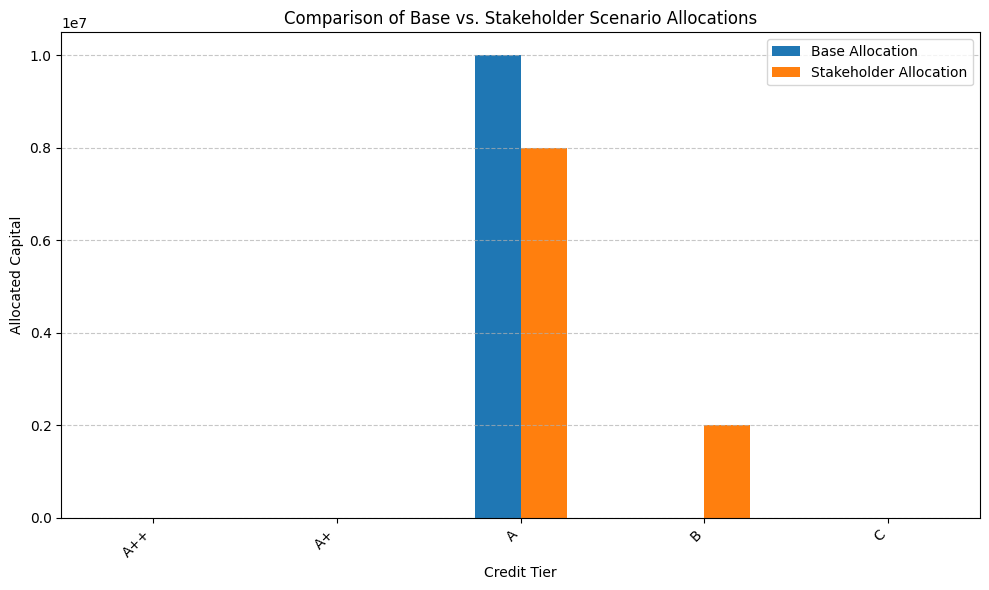


Objective Value Comparison:
Base Objective Value: 80,000,000
Stakeholder Objective Value: 70,500,000
Change in Objective Value: -9,500,000


In [36]:
# Comparison visualization: Part 1 vs Part 2 allocation (or objective)

# Create a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Credit Tier': options_df['credit_tier'],
    'Base Allocation': base_allocations,
    'Stakeholder Allocation': stakeholder_allocations
})

# Plotting allocations
fig, ax = plt.subplots(figsize=(10, 6))
comparison_df.set_index('Credit Tier').plot(kind='bar', ax=ax)
plt.title('Comparison of Base vs. Stakeholder Scenario Allocations')
plt.xlabel('Credit Tier')
plt.ylabel('Allocated Capital')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Also display objective values for clear comparison
print("\nObjective Value Comparison:")
print(f"Base Objective Value: {base_obj_val:,.0f}")
print(f"Stakeholder Objective Value: {stakeholder_obj_val:,.0f}")
print(f"Change in Objective Value: {stakeholder_obj_val - base_obj_val:,.0f}")

[TODO: Refer to your figure in 1–2 sentences, e.g. "The chart above shows…"]


### 4.4 Impact Analysis

**Instructions:** In 3–5 sentences: What changed in the recommendation? Why does it matter for the stakeholder? What would you tell them in a short briefing?

[TODO: Your impact analysis here.]


---
## Executive Summary

**Instructions:** Write a professional summary suitable for presenting to a decision-maker. Complete all subsections; no placeholder text or [TODO] in your final submission.

### Key Decision and Model
[TODO: What was allocated, across what options, objective/constraints (2–3 sentences).]

### Sensitivity Findings
[TODO: Which parameter mattered most; how solution responded to what-if (2–3 sentences).]

### Validation
[TODO: Sanity checks and robust/fragile conclusion (1–2 sentences).]

### Stakeholder Change (Part 2)
[TODO: What changed when the stakeholder changed their mind; how the recommendation shifted; what you would brief them (2–3 sentences).]

### Final Recommendation
[TODO: What to do and what to monitor (2–3 sentences).]

### Key Insights
[TODO: What you learned about parameters, sensitivity, validation, and responding to changing stakeholder needs (2–3 sentences).]


---
## Expectations: What to Check Before Submitting

Run through this checklist before you submit:

- **Is the Executive Summary there?** All subsections filled in (key decision and model, sensitivity findings, validation, stakeholder change, final recommendation, key insights). No placeholder text or "[TODO]" left.
- **Are there grammatical errors?** Proofread the markdown and narrative cells (especially the Executive Summary and impact analysis).
- **Are there formatting errors?** Headings, lists, and code output look correct. The notebook runs from top to bottom without errors.
- **Is this in a format you would hand off to a manager?** The narrative is professional and clear; a reader could use the Executive Summary without reading the code.
- **Are the graphics properly labeled and referenced in the text?** Every figure has a clear title and axis labels. In the markdown or summary, each figure is referred to (e.g. "As shown in the chart above…"). The reader knows what each graphic shows and why it matters.

The rubric used for grading is provided separately.
